In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf 

In [2]:
nsw_statistics = pd.read_csv("/Users/waqarmohiuddin/Library/Mobile Documents/com~apple~Numbers/Documents/NSW_trends.csv")

In [3]:
nsw_statistics

,,,,,,,,,,Table 1
Offence type,Jul 2015 - Jun 2016,Jul 2016 - Jun 2017,Jul 2017 - Jun 2018,Jul 2018 - Jun 2019,Jul 2019 - Jun 2020,Jul 2020 - Jun 2021,Jul 2021 - Jun 2022,Jul 2022 - Jun 2023,Jul 2023 - Jun 2024,Jul 2024 - Jun 2025
Murder *,60,71,54,79,72,58,65,54,74,75
Attempted murder,24,21,16,23,28,28,14,8,14,17
"Murder accessory, conspiracy",5,3,3,2,1,0,1,1,4,1
Manslaughter *,9,8,11,12,10,2,6,11,15,9
...,...,...,...,...,...,...,...,...,...,...
Fail to appear,751,701,531,496,704,789,910,866,710,157
Resist or hinder officer,"6,459","6,188","6,270","6,074","5,860","5,505","5,713","5,544","5,295","5,804"
Other offences against justice procedures,569,631,566,"1,100","1,845","1,898","2,060","2,635","2,253","2,087"
Transport regulatory offences,"113,037","130,222","123,858","109,235","99,537","74,549","64,944","71,891","65,976","58,335"


In [4]:
print(nsw_statistics.columns)

Index(['Table 1'], dtype='object')


In [5]:
nsw_stats = pd.read_csv("/Users/waqarmohiuddin/Library/Mobile Documents/com~apple~Numbers/Documents/NSW_trends_2.csv")

In [6]:
nsw_stats.columns = nsw_stats.columns.str.strip()

In [7]:
new_data = nsw_stats.set_index("Offence type")

In [8]:
new_data

,Jul 2015 - Jun 2016,Jul 2016 - Jun 2017,Jul 2017 - Jun 2018,Jul 2018 - Jun 2019,Jul 2019 - Jun 2020,Jul 2020 - Jun 2021,Jul 2021 - Jun 2022,Jul 2022 - Jun 2023,Jul 2023 - Jun 2024,Jul 2024 - Jun 2025
Offence type,,,,,,,,,,
Murder *,60,71,54,79,72,58,65,54,74,75
Attempted murder,24,21,16,23,28,28,14,8,14,17
"Murder accessory, conspiracy",5,3,3,2,1,0,1,1,4,1
Manslaughter *,9,8,11,12,10,2,6,11,15,9
Domestic violence related assault,"29,302","28,752","28,720","30,565","31,883","32,944","31,971","35,081","37,590","38,169"
...,...,...,...,...,...,...,...,...,...,...
Fail to appear,751,701,531,496,704,789,910,866,710,157
Resist or hinder officer,"6,459","6,188","6,270","6,074","5,860","5,505","5,713","5,544","5,295","5,804"
Other offences against justice procedures,569,631,566,"1,100","1,845","1,898","2,060","2,635","2,253","2,087"


In [9]:
new_data = new_data.apply(lambda x: x.str.replace(',', '').astype(int) if x.dtype == 'object' else x)

In [10]:
new_data

,Jul 2015 - Jun 2016,Jul 2016 - Jun 2017,Jul 2017 - Jun 2018,Jul 2018 - Jun 2019,Jul 2019 - Jun 2020,Jul 2020 - Jun 2021,Jul 2021 - Jun 2022,Jul 2022 - Jun 2023,Jul 2023 - Jun 2024,Jul 2024 - Jun 2025
Offence type,,,,,,,,,,
Murder *,60,71,54,79,72,58,65,54,74,75
Attempted murder,24,21,16,23,28,28,14,8,14,17
"Murder accessory, conspiracy",5,3,3,2,1,0,1,1,4,1
Manslaughter *,9,8,11,12,10,2,6,11,15,9
Domestic violence related assault,29302,28752,28720,30565,31883,32944,31971,35081,37590,38169
...,...,...,...,...,...,...,...,...,...,...
Fail to appear,751,701,531,496,704,789,910,866,710,157
Resist or hinder officer,6459,6188,6270,6074,5860,5505,5713,5544,5295,5804
Other offences against justice procedures,569,631,566,1100,1845,1898,2060,2635,2253,2087


In [11]:
nsw_long = new_data.reset_index().melt(id_vars="Offence type", 
                                var_name="Year", 
                                value_name="Count")

In [12]:
print(nsw_long)

                                  Offence type                 Year  Count
0                                     Murder *  Jul 2015 - Jun 2016     60
1                             Attempted murder  Jul 2015 - Jun 2016     24
2                 Murder accessory, conspiracy  Jul 2015 - Jun 2016      5
3                               Manslaughter *  Jul 2015 - Jun 2016      9
4            Domestic violence related assault  Jul 2015 - Jun 2016  29302
..                                         ...                  ...    ...
615                             Fail to appear  Jul 2024 - Jun 2025    157
616                   Resist or hinder officer  Jul 2024 - Jun 2025   5804
617  Other offences against justice procedures  Jul 2024 - Jun 2025   2087
618              Transport regulatory offences  Jul 2024 - Jun 2025  58335
619                             Other offences  Jul 2024 - Jun 2025  11628

[620 rows x 3 columns]


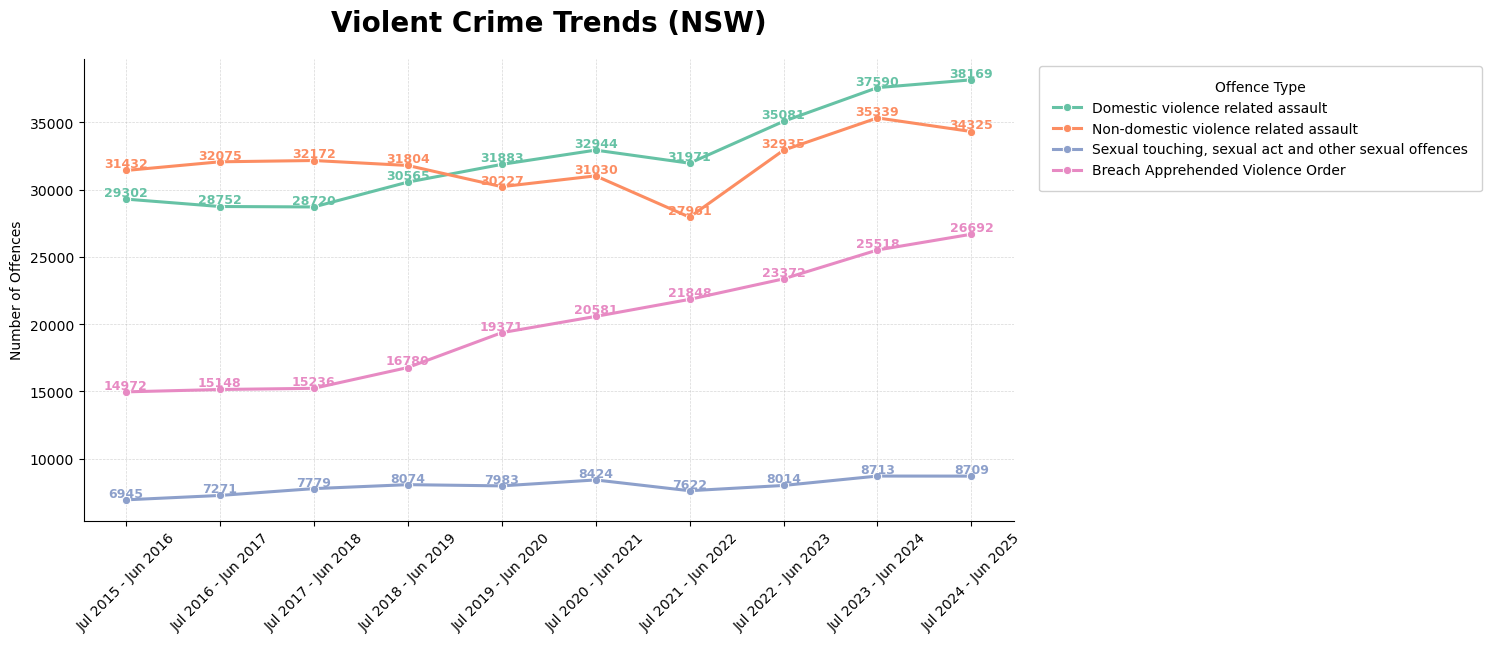

In [13]:
# Optional: choose a few offences to plot

#violent crime trends
offences_to_plot = ["Non-domestic violence related assault", "Domestic violence related assault", "Sexual touching, sexual act and other sexual offences", "Breach Apprehended Violence Order"]

plt.figure(figsize=(12,6))
ax = sns.lineplot(data=nsw_long[nsw_long["Offence type"].isin(offences_to_plot)],
             x="Year", y="Count", hue="Offence type", marker="o", palette= "Set2", linewidth = 2.2)

# Add numbers to each marker
for line, offence in zip(ax.lines, offences_to_plot):
    y = line.get_ydata()
    x = line.get_xdata()

    for xi, yi in zip(x, y):
        ax.text(
            xi,
            yi,
            f"{int(yi)}",        # the number
            fontsize=9,
            ha='center',
            va='bottom', 
            color=line.get_color(),
            fontweight="semibold"
        )

plt.title("Violent Crime Trends (NSW)", fontsize = 20, pad = 20, fontweight = "bold")
plt.xlabel(" ")
plt.ylabel("Number of Offences")
plt.xticks(rotation=45)
plt.grid(True, linestyle="--", linewidth=0.5, alpha=0.5)
plt.legend(
    title="Offence Type",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    frameon=True,
    framealpha=0.9,
    borderpad=1
)

sns.despine(top= True, right= True)
plt.show()



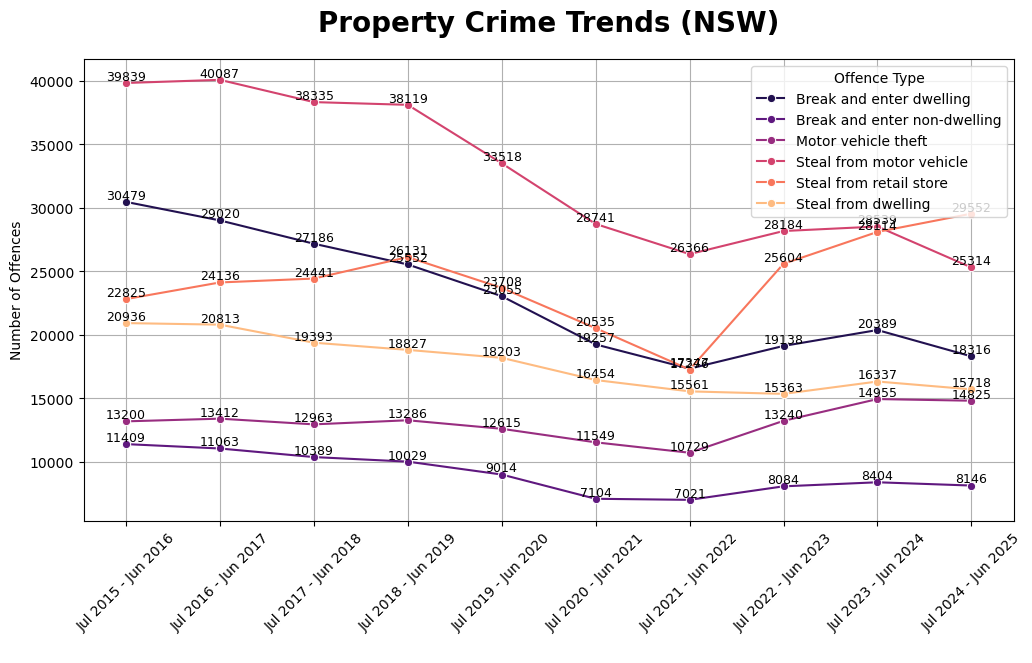

In [14]:
# Optional: choose a few offences to plot

#violent crime trends
offences_to_plot = ["Break and enter dwelling", "Break and enter non-dwelling", "Steal from motor vehicle", "Motor vehicle theft", "Steal from dwelling", "Steal from retail store"]

plt.figure(figsize=(12,6))
ax = sns.lineplot(data=nsw_long[nsw_long["Offence type"].isin(offences_to_plot)],
             x="Year", y="Count", hue="Offence type", marker="o", palette= "magma")

# Add numbers to each marker
for line, offence in zip(ax.lines, offences_to_plot):
    y = line.get_ydata()
    x = line.get_xdata()

    for xi, yi in zip(x, y):
        ax.text(
            xi,
            yi,
            f"{int(yi)}",        # the number
            fontsize=9,
            ha='center',
            va='bottom'
        )

plt.title("Property Crime Trends (NSW)", fontsize = 20, pad = 20, fontweight = "bold")
plt.xlabel(" ")
plt.ylabel("Number of Offences")
plt.xticks(rotation=45)
plt.grid(True)
plt.legend(title="Offence Type")
plt.show()

In [15]:
import matplotlib.ticker as mtick

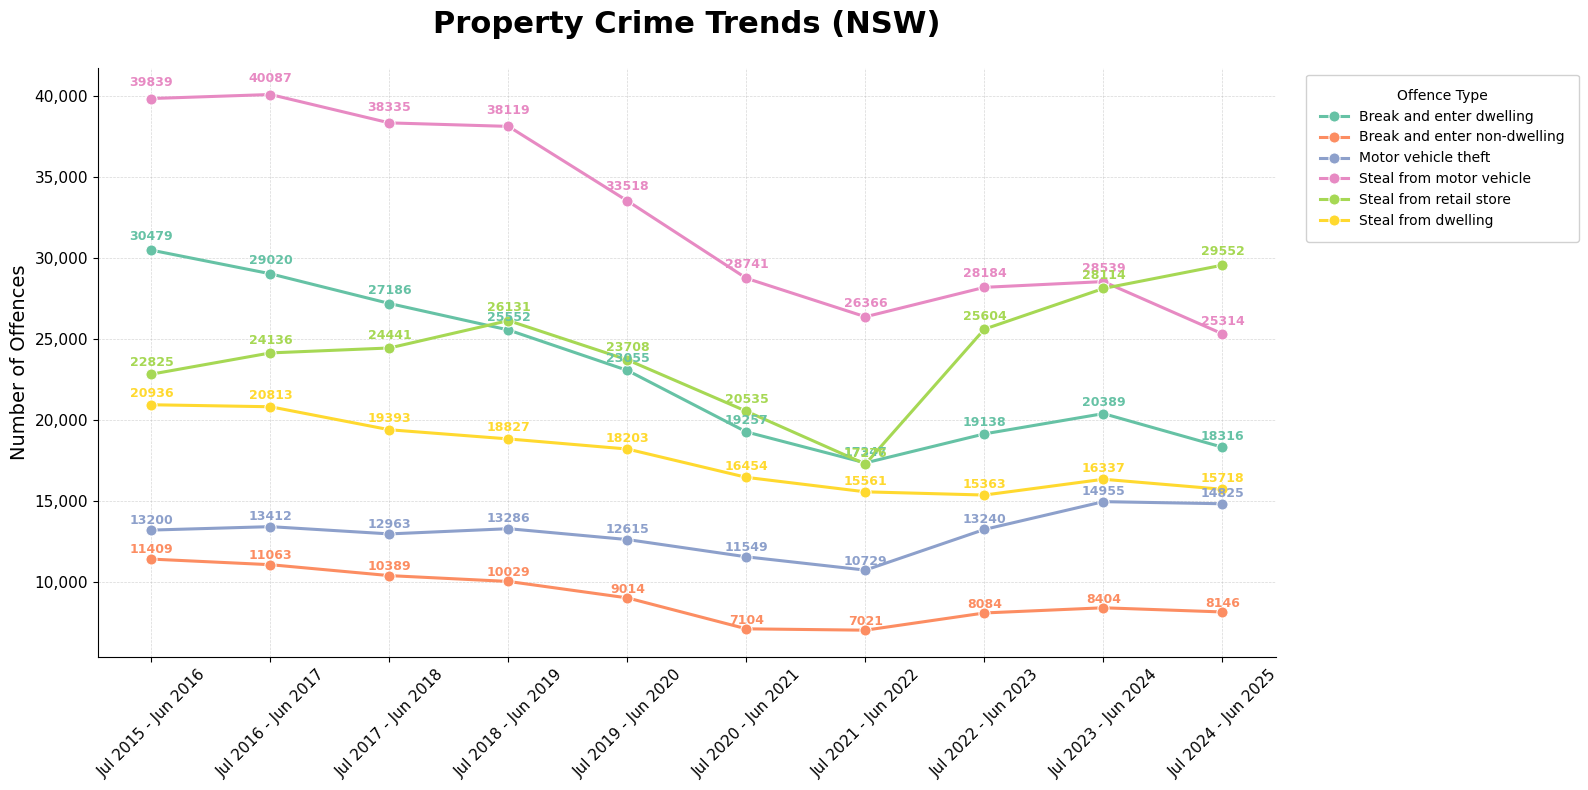

In [16]:
offences_to_plot = [
    "Break and enter dwelling",
    "Break and enter non-dwelling",
    "Steal from motor vehicle",
    "Motor vehicle theft",
    "Steal from dwelling",
    "Steal from retail store"
]

plt.figure(figsize=(16, 8))
ax = sns.lineplot(
    data=nsw_long[nsw_long["Offence type"].isin(offences_to_plot)],
    x="Year", y="Count",
    hue="Offence type",
    marker="o",
    linewidth=2.2,
    markersize=8,
    palette="Set2"
)

# Add numbers to markers (offset so they don't touch the point)
for line in ax.lines:
    y = line.get_ydata()
    x = line.get_xdata()

    for xi, yi in zip(x, y):
        ax.text(
            xi,
            yi + (yi * 0.015),  # slight vertical offset (1.5%)
            f"{int(yi)}",
            fontsize=9,
            ha="center",
            va="bottom",
            color=line.get_color(),
            fontweight="semibold"
        )

# Title + labels
plt.title(
    "Property Crime Trends (NSW)",
    fontsize=22,
    pad=25,
    fontweight="bold"
)

plt.xlabel("")
plt.ylabel("Number of Offences", fontsize=14)

plt.xticks(rotation=45, fontsize=11)
plt.yticks(fontsize=11)

# Soft grid
plt.grid(True, linestyle="--", linewidth=0.5, alpha=0.5)

# Legend moved outside right
plt.legend(
    title="Offence Type",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    frameon=True,
    framealpha=0.9,
    borderpad=1
)
ax.yaxis.set_major_formatter(mtick.StrMethodFormatter("{x:,.0f}"))  # adds commas
sns.despine(top=True, right=True)
plt.tight_layout()
plt.show()


In [17]:
nsw_long

,Offence type,Year,Count
0,Murder *,Jul 2015 - Jun 2016,60
1,Attempted murder,Jul 2015 - Jun 2016,24
2,"Murder accessory, conspiracy",Jul 2015 - Jun 2016,5
3,Manslaughter *,Jul 2015 - Jun 2016,9
4,Domestic violence related assault,Jul 2015 - Jun 2016,29302
...,...,...,...
615,Fail to appear,Jul 2024 - Jun 2025,157
616,Resist or hinder officer,Jul 2024 - Jun 2025,5804
617,Other offences against justice procedures,Jul 2024 - Jun 2025,2087
618,Transport regulatory offences,Jul 2024 - Jun 2025,58335


In [18]:
victoria_crime = pd.read_csv("/Users/waqarmohiuddin/Downloads/Data_Tables_Recorded_Offences_Visualisation_Year_Ending_June_2025/Table 01-Table 1.csv")

In [19]:
victoria_crime

,Year,Year ending,Offence Division,Offence Subdivision,Offence Subgroup,Offence Count,"Rate per 100,000 population"
0,2025,June,A Crimes against the person,A10 Homicide and related offences,A11 Murder,70,1.0
1,2025,June,A Crimes against the person,A10 Homicide and related offences,A12 Attempted murder,28,0.4
2,2025,June,A Crimes against the person,A10 Homicide and related offences,A14 Manslaughter & A13 Accessory/ conspiracy ...,28,0.4
3,2025,June,A Crimes against the person,A10 Homicide and related offences,A15 Driving causing death,102,1.4
4,2025,June,A Crimes against the person,A20 Assault and related offences,A211 FV Serious assault,9663,136.2
...,...,...,...,...,...,...,...
1123,2016,June,F Other offences,F90 Miscellaneous offences,F91 Environmental offences,67,1.1
1124,2016,June,F Other offences,F90 Miscellaneous offences,F92 Public health and safety offences,35,0.6
1125,2016,June,F Other offences,F90 Miscellaneous offences,F93 Cruelty to animals,284,4.6
1126,2016,June,F Other offences,F90 Miscellaneous offences,F94 Dangerous substance offences,25,0.4


In [20]:
victoria_crime_2 = victoria_crime[["Year", "Offence Subgroup", "Offence Count"]]

In [21]:
throwaway = victoria_crime_2.groupby("Year") [["Offence Subgroup", "Offence Count"]]

In [22]:
print(throwaway)

In [23]:
table = pd.pivot_table(
    victoria_crime_2,
    values='Offence Count',      # Column to aggregate
    index='Year',         # Rows = Year
    columns='Offence Subgroup',  # Columns = Offence types
    aggfunc='sum',               # Sum counts if there are duplicates
    fill_value=0                 # Replace missing values with 0
)

table

Offence Subgroup,A11 Murder,A12 Attempted murder,A14 Manslaughter & A13 Accessory/ conspiracy to murder,A15 Driving causing death,A211 FV Serious assault,A212 Non-FV Serious assault,"A22 Assault police, emergency services or other authorised officer",A231 FV Common assault,A232 Non-FV Common assault,A31 Rape,...,F33 Liquor and tobacco licensing offences,F34 Pornography and censorship offences,F35 Intellectual property,F36 Prostitution offences,F39 Other government regulatory offences,F91 Environmental offences,F92 Public health and safety offences,F93 Cruelty to animals,F94 Dangerous substance offences,F99 Other miscellaneous offences
Year,,,,,,,,,,,,,,,,,,,,,
2016,66,48,13,83,8628,8462,2919,12872,8784,4398,...,131,57,3,74,131,67,35,284,25,40
2017,56,92,13,72,8060,8681,3074,13892,9661,4273,...,145,32,5,76,83,53,27,159,13,55
2018,61,50,13,94,7664,8604,2865,13646,10650,4539,...,374,17,0,52,62,73,30,200,26,70
2019,53,33,19,85,7718,8184,3035,14451,11420,4320,...,118,10,1,33,73,51,130,167,60,59
2020,62,24,23,105,7909,7712,3057,15701,11199,4645,...,162,19,0,152,73,75,6080,231,26,89
2021,54,20,32,76,7431,7832,3364,16280,11306,4406,...,135,9,0,52,80,43,32266,189,31,44
2022,53,24,33,86,6892,7673,3084,15913,11674,4438,...,128,4,0,134,84,81,9924,170,26,139
2023,48,21,22,99,6844,7975,2964,16133,12998,4325,...,110,1,0,21,60,121,178,155,22,57
2024,55,34,12,115,7834,8053,2967,15855,13561,5098,...,289,3,0,6,76,153,37,248,83,39


In [24]:
table2 = pd.crosstab(
    victoria_crime_2['Offence Subgroup'],
    victoria_crime_2['Year'],
    values=victoria_crime_2['Offence Count'],
    aggfunc='sum'
).fillna(0)

table2

Year,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
Offence Subgroup,,,,,,,,,,
A11 Murder,66.0,56.0,61.0,53.0,62.0,54.0,53.0,48.0,55.0,70.0
A12 Attempted murder,48.0,92.0,50.0,33.0,24.0,20.0,24.0,21.0,34.0,28.0
A14 Manslaughter & A13 Accessory/ conspiracy to murder,13.0,13.0,13.0,19.0,23.0,32.0,33.0,22.0,12.0,28.0
A15 Driving causing death,83.0,72.0,94.0,85.0,105.0,76.0,86.0,99.0,115.0,102.0
A211 FV Serious assault,8628.0,8060.0,7664.0,7718.0,7909.0,7431.0,6892.0,6844.0,7834.0,9663.0
...,...,...,...,...,...,...,...,...,...,...
F91 Environmental offences,67.0,53.0,73.0,51.0,75.0,43.0,81.0,121.0,153.0,109.0
F92 Public health and safety offences,35.0,27.0,30.0,130.0,6080.0,32266.0,9924.0,178.0,37.0,32.0
F93 Cruelty to animals,284.0,159.0,200.0,167.0,231.0,189.0,170.0,155.0,248.0,214.0


In [25]:
victoria_crime_2

,Year,Offence Subgroup,Offence Count
0,2025,A11 Murder,70
1,2025,A12 Attempted murder,28
2,2025,A14 Manslaughter & A13 Accessory/ conspiracy ...,28
3,2025,A15 Driving causing death,102
4,2025,A211 FV Serious assault,9663
...,...,...,...
1123,2016,F91 Environmental offences,67
1124,2016,F92 Public health and safety offences,35
1125,2016,F93 Cruelty to animals,284
1126,2016,F94 Dangerous substance offences,25


In [26]:
table3 = victoria_crime_2.pivot(index='Offence Subgroup', columns='Year', values='Offence Count').round(1)

In [27]:
table3

Year,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
Offence Subgroup,,,,,,,,,,
A11 Murder,66.0,56.0,61.0,53.0,62.0,54.0,53.0,48.0,55.0,70.0
A12 Attempted murder,48.0,92.0,50.0,33.0,24.0,20.0,24.0,21.0,34.0,28.0
A14 Manslaughter & A13 Accessory/ conspiracy to murder,13.0,13.0,13.0,19.0,23.0,32.0,33.0,22.0,12.0,28.0
A15 Driving causing death,83.0,72.0,94.0,85.0,105.0,76.0,86.0,99.0,115.0,102.0
A211 FV Serious assault,8628.0,8060.0,7664.0,7718.0,7909.0,7431.0,6892.0,6844.0,7834.0,9663.0
...,...,...,...,...,...,...,...,...,...,...
F91 Environmental offences,67.0,53.0,73.0,51.0,75.0,43.0,81.0,121.0,153.0,109.0
F92 Public health and safety offences,35.0,27.0,30.0,130.0,6080.0,32266.0,9924.0,178.0,37.0,32.0
F93 Cruelty to animals,284.0,159.0,200.0,167.0,231.0,189.0,170.0,155.0,248.0,214.0


In [28]:
offences_of_interest = ["A231 FV Common assault", ""]

In [29]:
grouped = victoria_crime.groupby(['Offence Subdivision', 'Year'])['Offence Count'].sum().reset_index()

# Pivot so that years are columns and offence groups are rows
pivot = grouped.pivot(index='Offence Subdivision', columns='Year', values='Offence Count').fillna(0)

In [30]:
vic_crime_data = pivot.copy()

In [31]:
vic_crime_data

Year,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
Offence Subdivision,,,,,,,,,,
A10 Homicide and related offences,210,233,218,190,214,182,196,190,216,228
A20 Assault and related offences,41665,43368,43429,44808,45578,46213,45236,46914,48270,53854
A30 Sexual offences,12659,13472,14698,13461,13854,14997,13557,14012,16497,17344
A40 Abduction and related offences,807,756,722,735,723,774,734,621,722,863
A50 Robbery,2887,3195,3181,3432,3888,2529,2352,2862,3280,3828
A60 Blackmail and extortion,191,204,188,255,229,246,345,800,466,510
"A70 Stalking, harassment and threatening behaviour",12713,11823,11731,12309,12601,14350,13286,12704,13361,14689
A80 Dangerous and negligent acts endangering people,5344,6086,5899,5881,5917,6106,6363,6090,6131,6574
B10 Arson,4518,3264,3348,3155,2631,2088,2149,2179,2819,3938


In [32]:
crimes = ["A211 FV Serious assault",
"A212 Non-FV Serious assault",
"A22 Assault police, emergency services or other authorised officer",
"A231 FV Common assault",
"A232 Non-FV Common assault"]

criminal_vic = victoria_crime[victoria_crime["Offence Subgroup"].isin(crimes)]

In [33]:
criminal_vic2 = criminal_vic[["Year", "Offence Subgroup", "Offence Count"]]

In [34]:
criminal_vic2.plot

In [35]:
pivot = criminal_vic2.pivot_table(
    index='Year',
    columns='Offence Subgroup',
    values='Offence Count',
    aggfunc='sum',
    fill_value=0
)

# Convert counts to proportions per year
prop = pivot.div(pivot.sum(axis=1), axis=0)

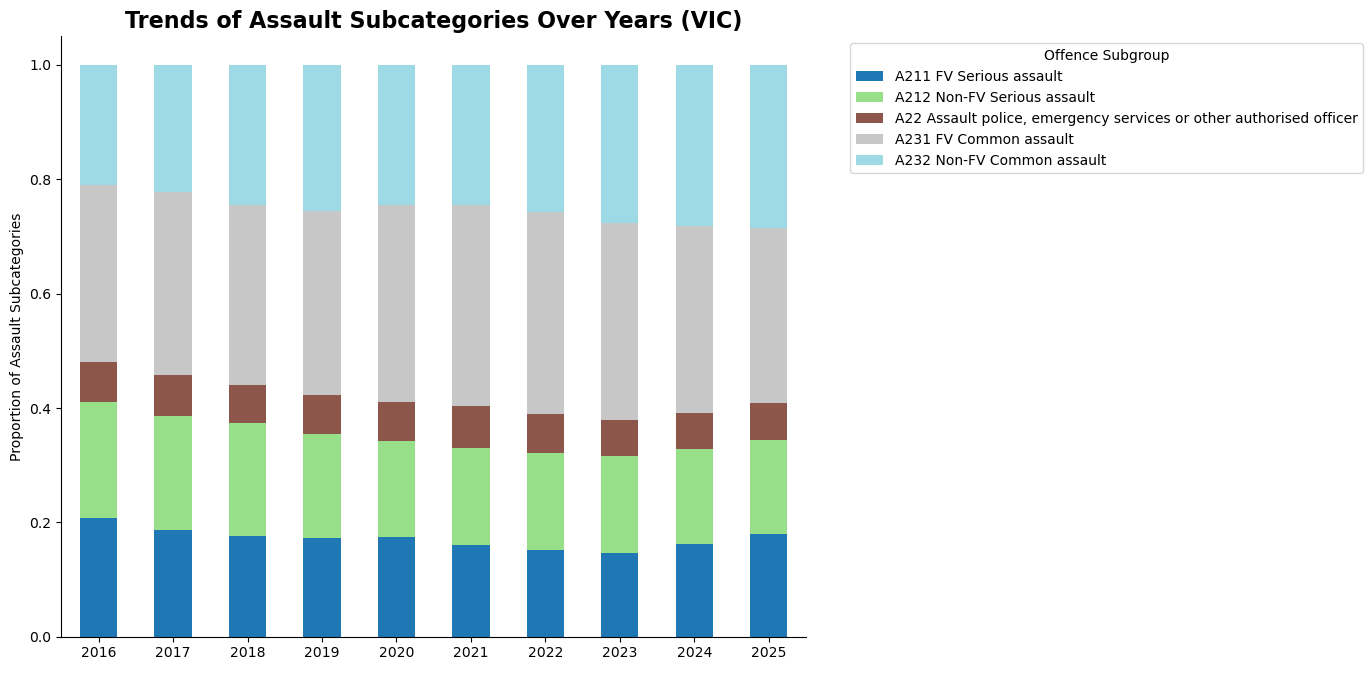

In [36]:
# Plot
prop.plot(
    kind='bar',
    stacked=True,
    figsize=(14,7),
    colormap='tab20'  # nice distinct colors
)
sns.despine(top=True, right=True)
plt.ylabel("Proportion of Assault Subcategories")
plt.xlabel(" ")
plt.title("Trends of Assault Subcategories Over Years (VIC)", fontsize=16, fontweight='bold')
plt.legend(title="Offence Subgroup", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [37]:
vic_crime_data_long = vic_crime_data.reset_index().melt(
    id_vars="Offence Subdivision",
    var_name="Year",
    value_name="Count"
)

# Make sure Year is numeric
vic_crime_data_long["Year"] = vic_crime_data_long["Year"].astype(int)

In [38]:
vic_crime_data_long

,Offence Subdivision,Year,Count
0,A10 Homicide and related offences,2016,210
1,A20 Assault and related offences,2016,41665
2,A30 Sexual offences,2016,12659
3,A40 Abduction and related offences,2016,807
4,A50 Robbery,2016,2887
...,...,...,...
275,E20 Breaches of orders,2025,84353
276,F10 Regulatory driving offences,2025,63
277,F20 Transport regulation offences,2025,437
278,F30 Other government regulatory offences,2025,620


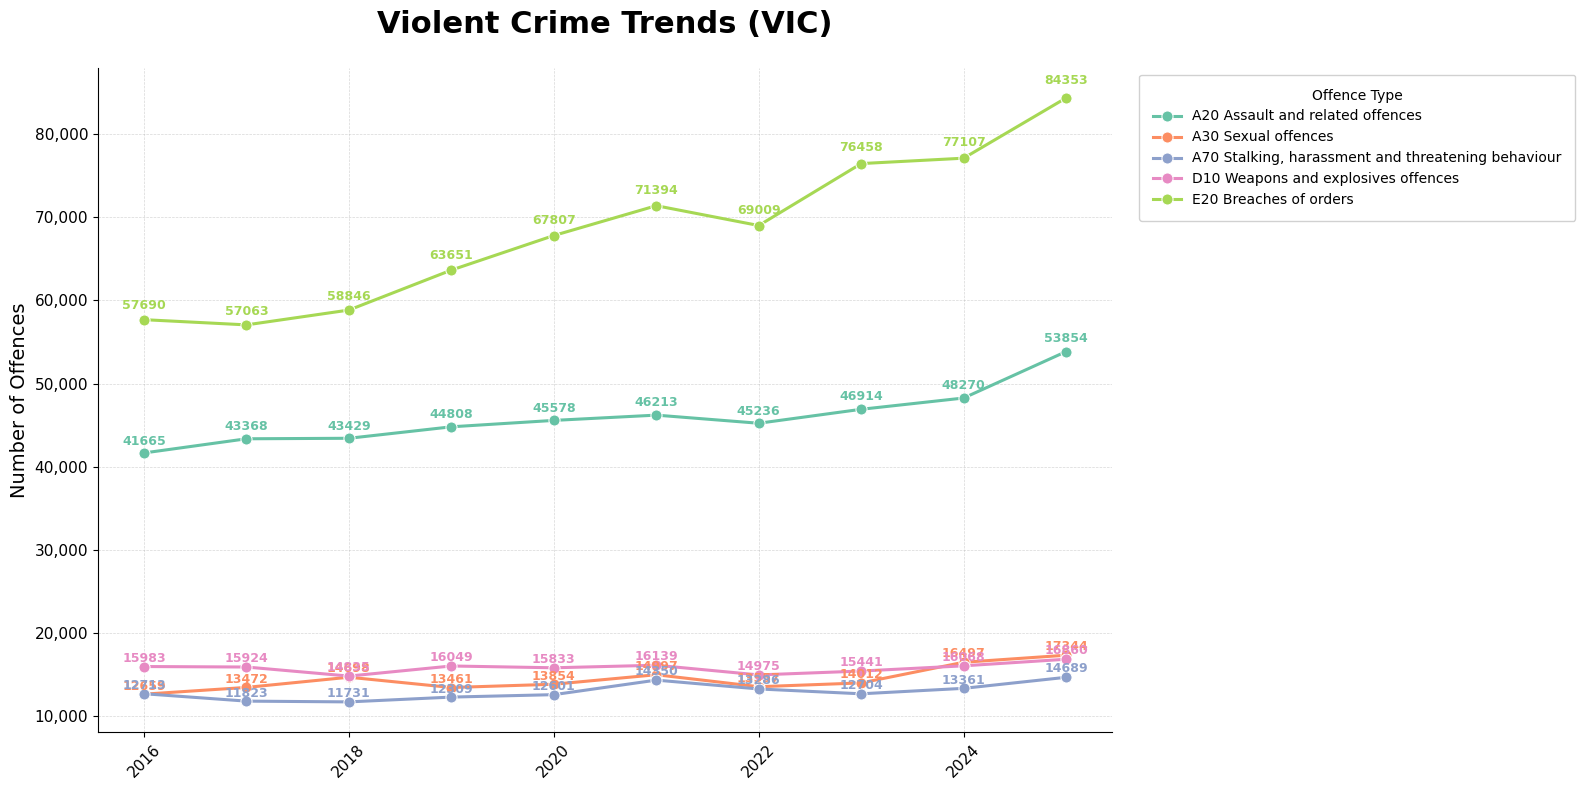

In [39]:


offences_vic = [
    "A20 Assault and related offences",
    "A30 Sexual offences",
    "A70 Stalking, harassment and threatening behaviour",
    "D10 Weapons and explosives offences", 
    "E20 Breaches of orders"
]

plt.figure(figsize=(16, 8))
ax = sns.lineplot(
    data= vic_crime_data_long[vic_crime_data_long["Offence Subdivision"].isin(offences_vic)],
    x="Year", y="Count",
    hue="Offence Subdivision",
    marker="o",
    linewidth=2.2,
    markersize=8,
    palette="Set2"
)

# Add numbers to markers (offset so they don't touch the point)
for line in ax.lines:
    y = line.get_ydata()
    x = line.get_xdata()

    for xi, yi in zip(x, y):
        ax.text(
            xi,
            yi + (yi * 0.015),  # slight vertical offset (1.5%)
            f"{int(yi)}",
            fontsize=9,
            ha="center",
            va="bottom",
            color=line.get_color(),
            fontweight="semibold"
        )

# Title + labels
plt.title(
    "Violent Crime Trends (VIC)",
    fontsize=22,
    pad=25,
    fontweight="bold"
)

plt.xlabel("")
plt.ylabel("Number of Offences", fontsize=14)

plt.xticks(rotation=45, fontsize=11)
plt.yticks(fontsize=11)

# Soft grid
plt.grid(True, linestyle="--", linewidth=0.5, alpha=0.5)

# Legend moved outside right
plt.legend(
    title="Offence Type",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    frameon=True,
    framealpha=0.9,
    borderpad=1
)
ax.yaxis.set_major_formatter(mtick.StrMethodFormatter("{x:,.0f}"))  # adds commas
sns.despine(top=True, right=True)
plt.tight_layout()
plt.show()

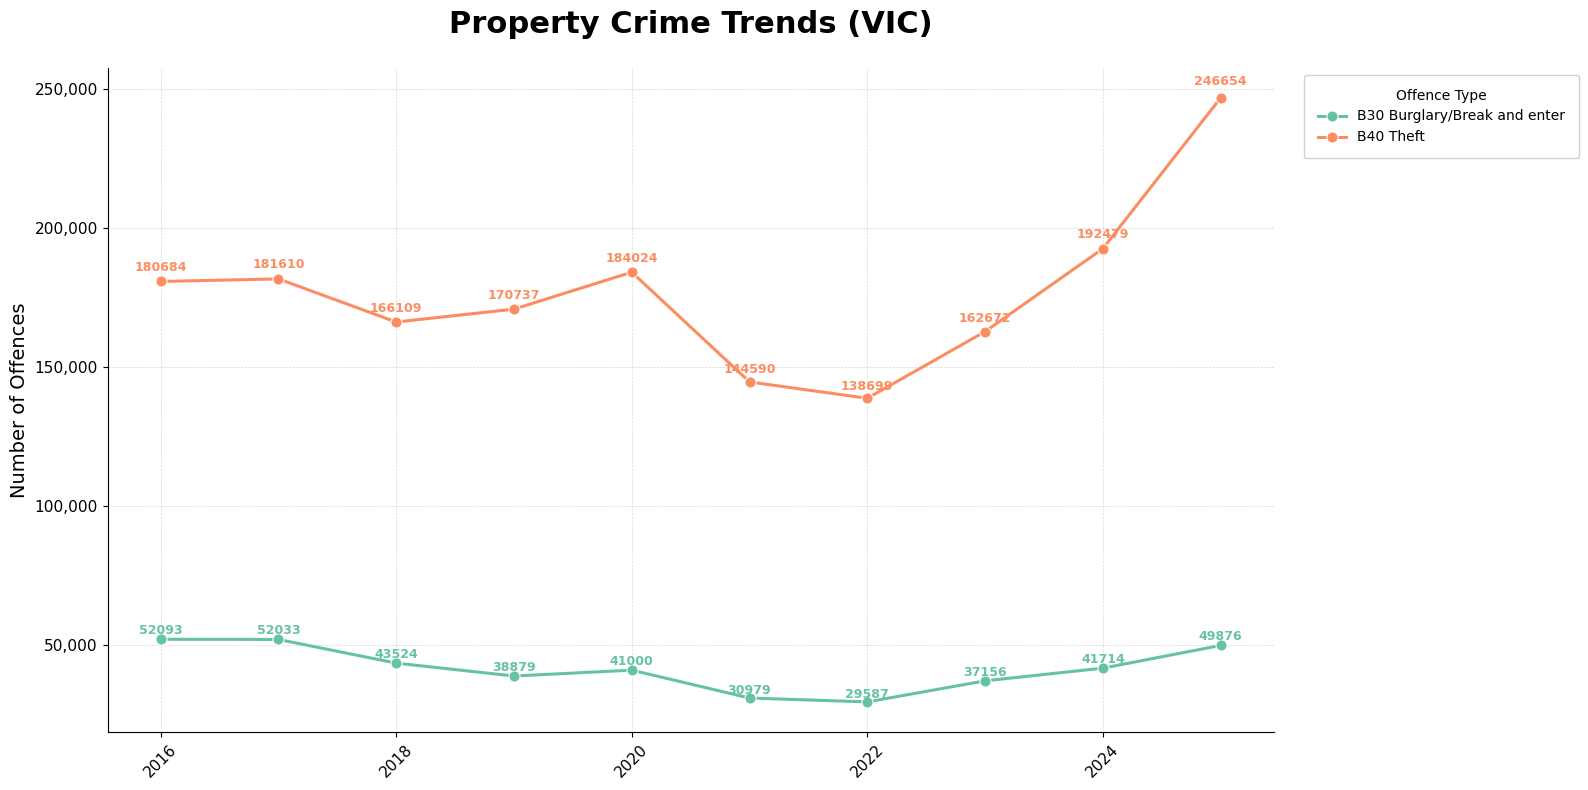

In [51]:
offences_vic2 = [
    "B30 Burglary/Break and enter",
    "B40 Theft",
]

plt.figure(figsize=(16, 8))
ax = sns.lineplot(
    data= vic_crime_data_long[vic_crime_data_long["Offence Subdivision"].isin(offences_vic2)],
    x="Year", y="Count",
    hue="Offence Subdivision",
    marker="o",
    linewidth=2.2,
    markersize=8,
    palette="Set2"
)

# Add numbers to markers (offset so they don't touch the point)
for line in ax.lines:
    y = line.get_ydata()
    x = line.get_xdata()

    for xi, yi in zip(x, y):
        ax.text(
            xi,
            yi + (yi * 0.015),  # slight vertical offset (1.5%)
            f"{int(yi)}",
            fontsize=9,
            ha="center",
            va="bottom",
            color=line.get_color(),
            fontweight="semibold"
        )

# Title + labels
plt.title(
    "Property Crime Trends (VIC)",
    fontsize=22,
    pad=25,
    fontweight="bold"
)

plt.xlabel("")
plt.ylabel("Number of Offences", fontsize=14)

plt.xticks(rotation=45, fontsize=11)
plt.yticks(fontsize=11)

# Soft grid
plt.grid(True, linestyle="--", linewidth=0.5, alpha=0.5)

# Legend moved outside right
plt.legend(
    title="Offence Type",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    frameon=True,
    framealpha=0.9,
    borderpad=1
)
ax.yaxis.set_major_formatter(mtick.StrMethodFormatter("{x:,.0f}"))  # adds commas
sns.despine(top=True, right=True)
plt.tight_layout()
plt.show()

In [41]:
melb_youth_crime = pd.read_csv("/Users/waqarmohiuddin/Downloads/Data_Tables_Alleged_Offender_Incidents_Visualisation_Year_Ending_June_2025/Table 02-Table 1.csv")

In [42]:
melb_youth_crime

youth_vic = melb_youth_crime[["Year", "Sex", "Age Group", "Alleged Offender Incidents"]]

youth_vic


,Year,Sex,Age Group,Alleged Offender Incidents
0,2025,Females,10-14 years,2139
1,2025,Females,15-17 years,4114
2,2025,Females,18-19 years,1773
3,2025,Females,20-24 years,4787
4,2025,Females,25-29 years,5498
...,...,...,...,...
485,2016,People,60-64 years,1591
486,2016,People,65-69 years,936
487,2016,People,70-74 years,485
488,2016,People,75 years and over,433


In [43]:
female = ["Females"]

female_youth_vic = youth_vic[youth_vic["Sex"].isin(female)]

female_youth_vic

female_grouped = female_youth_vic.groupby(['Age Group', 'Year'])['Alleged Offender Incidents'].sum().reset_index()

In [44]:
pivot_females = female_grouped.pivot(index='Age Group', columns='Year', values='Alleged Offender Incidents').fillna(0)

In [45]:
age_map = {
    "10-14 years": "10–17",
    "15-17 years": "10–17",
    "18-19 years": "18–29",
    "20-24 years": "18–29",
    "25-29 years": "18–29",
    "30-34 years": "30–44",
    "35-39 years": "30–44",
    "40-44 years": "30–44",
    "45-49 years": "45–59",
    "50-54 years": "45–59",
    "55-59 years": "45–59",
    "60-64 years": "60+",
    "65-69 years": "60+",
    "70-74 years": "60+",
    "75 years and over": "60+",
}

pivot_females["Age Group Grouped"] = pivot_females.index.map(age_map)
females_vic_crime = pivot_females.groupby("Age Group Grouped").sum()

In [46]:
females_vic_crime


female_vic_crime_data_long = females_vic_crime.reset_index().melt(
    id_vars="Age Group Grouped",
    var_name="Year",
    value_name="Count"
)


female_vic_crime_data_long

,Age Group Grouped,Year,Count
0,10–17,2016,3905
1,18–29,2016,11606
2,30–44,2016,10678
3,45–59,2016,3472
4,60+,2016,597
5,10–17,2017,4349
6,18–29,2017,11781
7,30–44,2017,11418
8,45–59,2017,3840
9,60+,2017,609


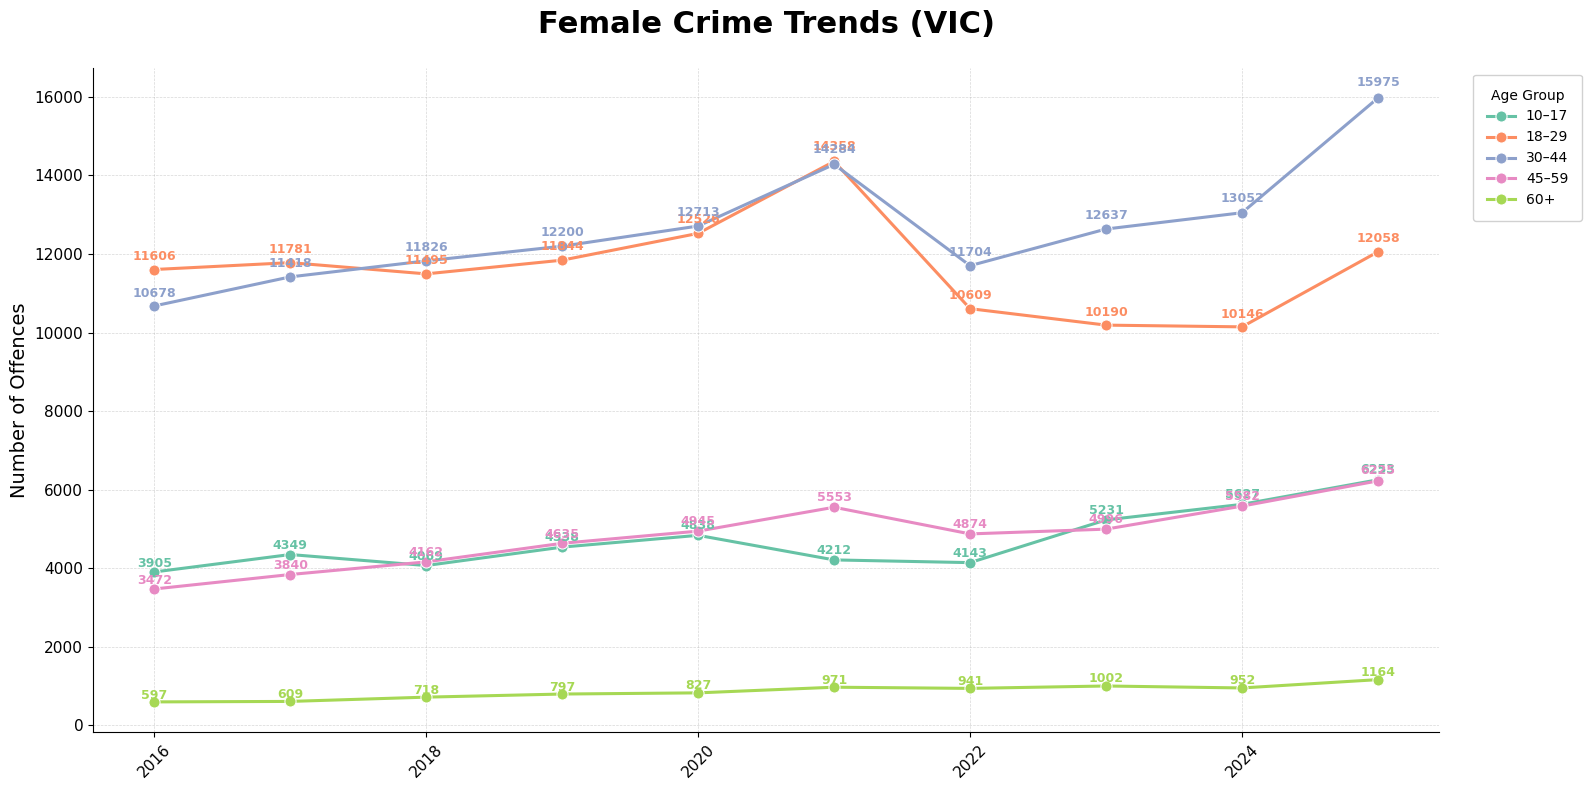

In [47]:
plt.figure(figsize=(16, 8))
ax = sns.lineplot(
    data= female_vic_crime_data_long,
    x="Year", y="Count",
    hue="Age Group Grouped",
    marker="o",
    linewidth=2.2,
    markersize=8,
    palette="Set2"  
)

# Add numbers to markers (offset so they don't touch the point)
for line in ax.lines:
    y = line.get_ydata()
    x = line.get_xdata()

    for xi, yi in zip(x, y):
        ax.text(
            xi,
            yi + (yi * 0.015),  # slight vertical offset (1.5%)
            f"{int(yi)}",
            fontsize=9,
            ha="center",
            va="bottom",
            color=line.get_color(),
            fontweight="semibold"
        )

# Title + labels
plt.title(
    "Female Crime Trends (VIC)",
    fontsize=22,
    pad=25,
    fontweight="bold"
)

plt.xlabel("")
plt.ylabel("Number of Offences", fontsize=14)

plt.xticks(rotation=45, fontsize=11)
plt.yticks(fontsize=11)

# Soft grid
plt.grid(True, linestyle="--", linewidth=0.5, alpha=0.5)

# Legend moved outside right
plt.legend(
    title="Age Group",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    frameon=True,
    framealpha=0.9,
    borderpad=1
)
sns.despine(top=True, right=True)
plt.tight_layout()
plt.show()

In [48]:
ages = ["10-14 years", "15-17 years"]

youth_crime_in_general = melb_youth_crime[melb_youth_crime["Age Group"].isin(ages)]

youth_criminal_incidents = youth_crime_in_general[["Year", "Age Group", "Alleged Offender Incidents"]]

In [49]:
youth_criminal_incidents

youth_grouped = youth_criminal_incidents.groupby(['Age Group', 'Year'])['Alleged Offender Incidents'].sum().reset_index()

In [50]:
from matplotlib

SyntaxError: invalid syntax (1271150538.py, line 1)

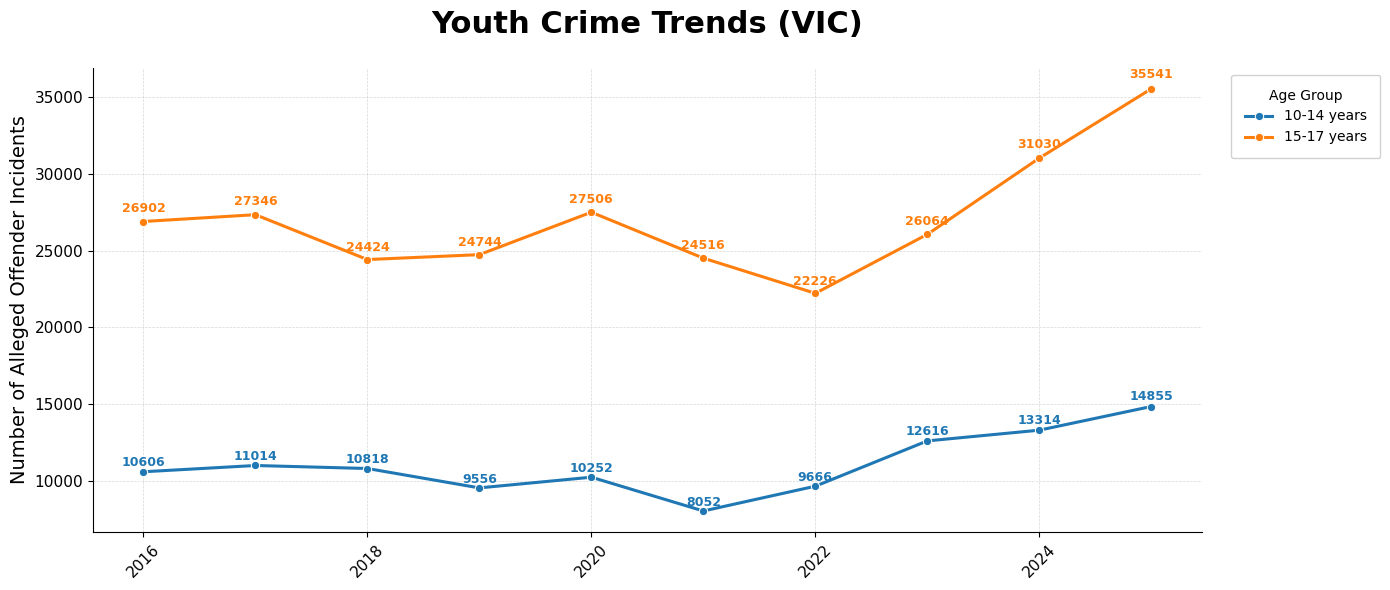

In [ ]:
youth_grouped

plt.figure(figsize=(14,6))
ax = sns.lineplot(
    data=youth_grouped,
    x='Year',
    y='Alleged Offender Incidents',
    hue='Age Group',
    marker='o', 
    linewidth = 2.2
)

# Add numbers to markers (offset so they don't touch the point)
for line in ax.lines:
    y = line.get_ydata()
    x = line.get_xdata()

    for xi, yi in zip(x, y):
        ax.text(
            xi,
            yi + (yi * 0.015),  # slight vertical offset (1.5%)
            f"{int(yi)}",
            fontsize=9,
            ha="center",
            va="bottom",
            color=line.get_color(),
            fontweight="semibold"
        )

# Title + labels
plt.title(
    "Youth Crime Trends (VIC)",
    fontsize=22,
    pad=25,
    fontweight="bold"
)

plt.xlabel("")
plt.ylabel("Number of Alleged Offender Incidents", fontsize=14)

plt.xticks(rotation=45, fontsize=11)
plt.yticks(fontsize=11)

# Soft grid
plt.grid(True, linestyle="--", linewidth=0.5, alpha=0.5)

# Legend moved outside right
plt.legend(
    title="Age Group",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    frameon=True,
    framealpha=0.9,
    borderpad=1
)

sns.despine(top=True, right=True)

plt.tight_layout()
plt.show()



In [ ]:
abs_data = pd.read_csv("/Users/waqarmohiuddin/Downloads/ABS stats 3.csv", header = 0)

In [ ]:
abs_data = abs_data.rename(columns={"Year": "Principal Offence"})

In [ ]:


year_cols = [c for c in abs_data.columns if "20" in str(c)]

abs_data_long = abs_data.melt(
    id_vars="Principal Offence",
    value_vars=year_cols,
    var_name="Year",
    value_name="Count"
)

In [ ]:
abs_data_long.at[0, "Principal offence(b)(c)"] = "Homicide and related offences"


In [ ]:
abs_data_long2 = abs_data_long[["Principal Offence", "Year", "Count"]]

In [ ]:
abs_data_long2

abs_data_long2.loc[abs_data_long2["Principal Offence"] == "Principal offence(b)(c)", "Principal Offence"] = "Homicide"

/var/folders/l0/k4x186gj0bb144vhk6pmyc3c0000gn/T/ipykernel_79335/4063890326.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  abs_data_long2.loc[abs_data_long2["Principal Offence"] == "Principal offence(b)(c)", "Principal Offence"] = "Homicide"


In [ ]:

abs_data_long2[abs_data_long2["Principal Offence"].str.contains("Principal", na=False)]

,Principal Offence,Year,Count
0,Principal offence(b)(c),2008–09,816
38,Principal offence(b)(c),2009–10,880
76,Principal offence(b)(c),2010–11,757
114,Principal offence(b)(c),2011–12,661
152,Principal offence(b)(c),2012–13,728
190,Principal offence(b)(c),2013–14,677
228,Principal offence(b)(c),2014–15,712
266,Principal offence(b)(c),2015–16,702
304,Principal offence(b)(c),2016–17,665
342,Principal offence(b)(c),2017–18,683


In [ ]:
abs_data_long2.iloc[0, abs_data_long2.columns.get_loc("Principal Offence")] = "Homicide"

/var/folders/l0/k4x186gj0bb144vhk6pmyc3c0000gn/T/ipykernel_79335/232835808.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  abs_data_long2.iloc[0, abs_data_long2.columns.get_loc("Principal Offence")] = "Homicide"


In [ ]:
abs_data_long2

,Principal Offence,Year,Count
0,Homicide,2008–09,816
1,011 Murder,2008–09,318
2,012 Attempted Murder,2008–09,232
3,013 Manslaughter and driving causing death,2008–09,260
4,02 Acts intended to cause injury(f),2008–09,"72,069"
...,...,...,...
603,15 Offences against justice(n)(o),2023-24,"31,101"
604,153 Breach of violence and non-violence orders,2023-24,"20,073"
605,156 Offences against justice procedures,2023-24,"7,620"
606,16 Miscellaneous offences,2023-24,"9,876"


In [ ]:
import matplotlib.ticker as mtick



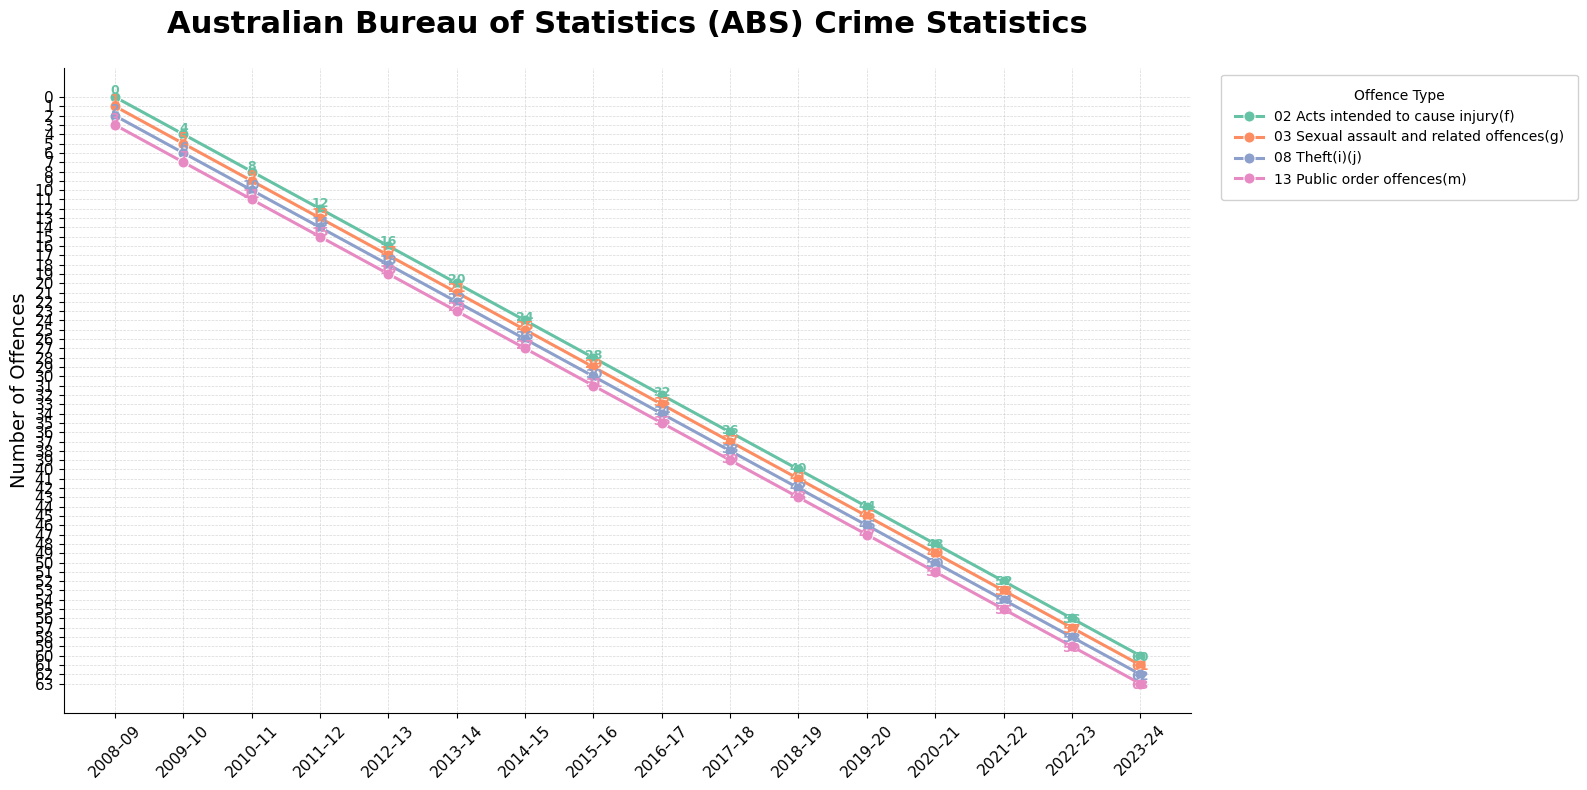

In [ ]:
measures = [ "02 Acts intended to cause injury(f)", "03 Sexual assault and related offences(g)", "13 Public order offences(m)", "08 Theft(i)(j)"]

plt.figure(figsize=(16, 8))
ax = sns.lineplot(
    data= abs_data_long2[abs_data_long2["Principal Offence"].isin(measures)],
    x="Year", y="Count",
    hue="Principal Offence",
    marker="o",
    linewidth=2.2,
    markersize=8,
    palette="Set2"
)

# Add numbers to markers (offset so they don't touch the point)
for line in ax.lines:
    y = line.get_ydata()
    x = line.get_xdata()

    for xi, yi in zip(x, y):
        ax.text(
            xi,
            yi + (yi * 0.015),  # slight vertical offset (1.5%)
            f"{int(yi)}",
            fontsize=9,
            ha="center",
            va="bottom",
            color=line.get_color(),
            fontweight="semibold"
        )

# Title + labels
plt.title(
    "Australian Bureau of Statistics (ABS) Crime Statistics",
    fontsize=22,
    pad=25,
    fontweight="bold"
)

plt.xlabel("")
plt.ylabel("Number of Offences", fontsize=14)

plt.xticks(rotation=45, fontsize=11)
plt.yticks(fontsize=11)

# Soft grid
plt.grid(True, linestyle="--", linewidth=0.5, alpha=0.5)

# Legend moved outside right
plt.legend(
    title="Offence Type",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    frameon=True,
    framealpha=0.9,
    borderpad=1
)
ax.yaxis.set_major_formatter(mtick.StrMethodFormatter("{x:,.0f}"))  # adds commas
sns.despine(top=True, right=True)
plt.tight_layout()
plt.show()